---
**Title:** 流水并行论 (Pipeline Parallelism, PP)

**Category:** pipeline-parallelism

**Difficulty:** 中

**Estimated Time:** 半个时辰

---

## 总论

设模型之大，一器不能容，奈何？自然之策曰：**分层布于多器**，每器各司其职，仅持模型之一隅。

此即**流水并行**之术也。本篇将循序渐进，自最朴素之法始，步步精进。

### 先修

- PyTorch 基础（`nn.Module`、`nn.Sequential`）
- 知前向传播与反向传播之理
- 宜先阅：[〇〇 — GPU 通信原语](00-gpu-communication.ipynb) 与 [〇一 — 数据并行](01-data-parallelism.ipynb)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

# Our visualization helpers
from mp_tutorial.viz import draw_data_flow, draw_naive_vs_pipeline, draw_pipeline_timeline
from mp_tutorial.formatting import info_box, gpu_required_banner, comparison_table, code_reference
from mp_tutorial.distributed import check_gpu_env, simulate_pipeline_stages
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

check_gpu_env()

✗ No CUDA GPU detected on this machine.

To run GPU-required cells, use a machine with CUDA GPUs (4+ recommended).
See README.md for remote Jupyter setup instructions.


## 原理

### 其一：最朴之法 —— 分层而治

设有八层之模型、四器可用，最自然之分法如下：

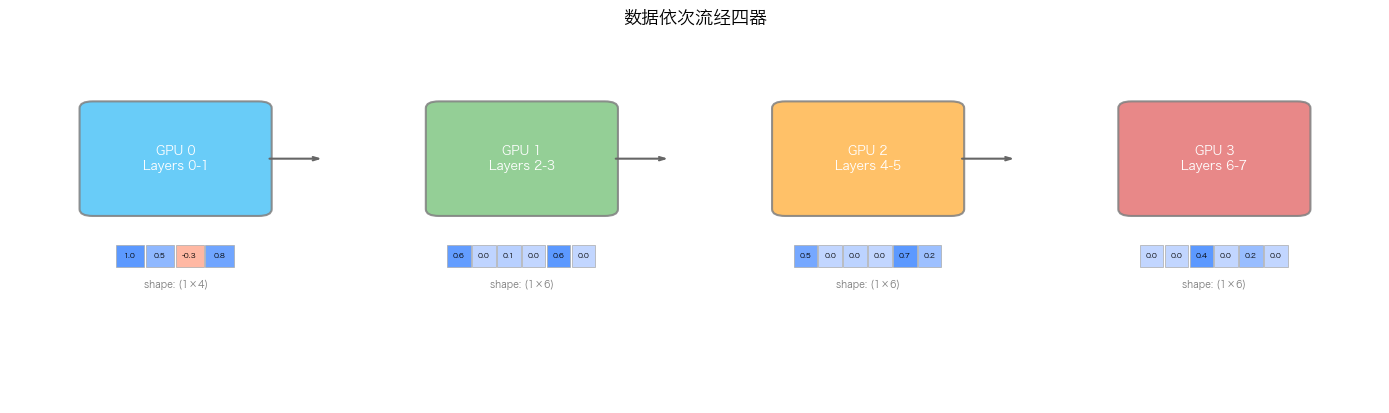

In [2]:
# Let's build a tiny model and watch data flow through it
torch.manual_seed(42)

# A simple 8-layer model (4 stages × 2 layers each)
model = nn.Sequential(
    nn.Linear(4, 6), nn.ReLU(),   # Stage 0 (GPU 0)
    nn.Linear(6, 6), nn.ReLU(),   # Stage 1 (GPU 1)
    nn.Linear(6, 6), nn.ReLU(),   # Stage 2 (GPU 2)
    nn.Linear(6, 3), nn.ReLU(),   # Stage 3 (GPU 3)
)

# One small input batch
x = torch.tensor([[1.0, 0.5, -0.3, 0.8]])

# Run through each stage and capture the intermediate tensors
stage_layers = [
    nn.Sequential(model[0], model[1]),  # GPU 0
    nn.Sequential(model[2], model[3]),  # GPU 1
    nn.Sequential(model[4], model[5]),  # GPU 2
    nn.Sequential(model[6], model[7]),  # GPU 3
]

snapshots = [x]
h = x
for stage in stage_layers:
    with torch.no_grad():
        h = stage(h)
    snapshots.append(h)

# Visualize: data flowing through each GPU
draw_data_flow(
    stage_labels=["GPU 0\nLayers 0-1", "GPU 1\nLayers 2-3",
                  "GPU 2\nLayers 4-5", "GPU 3\nLayers 6-7"],
    data_snapshots=snapshots,
    title="数据依次流经四器"
)
plt.show()

输入先至第零器，零器之输出传于第一器，依次递之。至简也！

然有**大患**：当第一器运算之时，零、二、三器皆**空闲**。试观之：

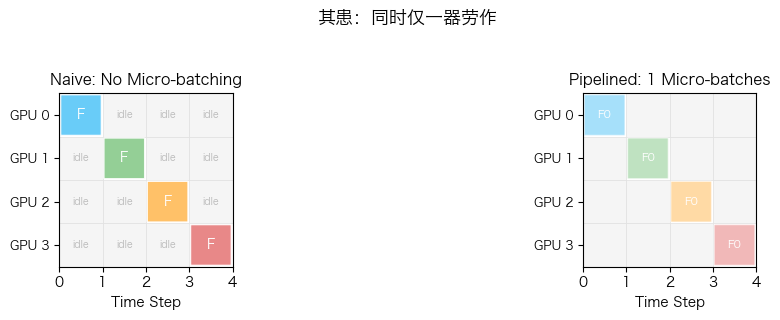

In [3]:
# Left: naive (1 batch, sequential)  vs  Right: with micro-batching
draw_naive_vs_pipeline(num_stages=4, num_microbatches=1, title="其患：同时仅一器劳作")
plt.show()

四器而仅一器劳作，**算力之七成五皆废**。须思良策。

### 其二：微批（Micro-batching）—— 充盈流水

其法曰：勿以一大批数据径送之，宜**拆为细小之份，名曰微批**。

> **何谓微批？** 常训练时，一次取一"批"样本（如六十四图）。微批者，将此批切为更细之块 —— 如八微批，每批八图。模型所见之数据不变，惟每次所食者少。

其妙曰：微批其一尚未走遍诸器，便已将微批其二**送入**第零器矣。如此则多器可并工：

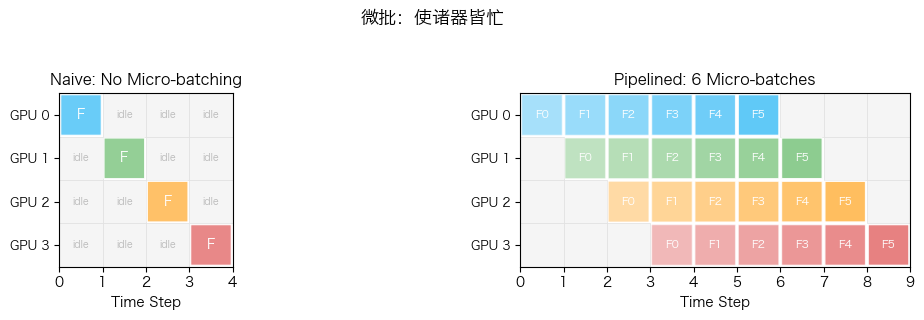

以 4 阶段、6 微批计：
  总时步：9
  每器空闲步数：3
  泡比：3/9 = 33%

→ 微批愈多，废愈少！


In [4]:
# Now with 6 micro-batches — see how the pipeline fills up!
draw_naive_vs_pipeline(num_stages=4, num_microbatches=6,
                       title="微批：使诸器皆忙")
plt.show()

# How much time is wasted?
p, m = 4, 6
total = m + p - 1
bubble = p - 1
print(f"以 {p} 阶段、{m} 微批计：")
print(f"  总时步：{total}")
print(f"  每器空闲步数：{bubble}")
print(f"  泡比：{bubble}/{total} = {bubble/total:.0%}")
print(f"\n→ 微批愈多，废愈少！")

灰者即**流水之泡**（bubble）—— 器闲而待数据至或结果传递之时也。

> **何以名之曰"泡"？** 试思水管中之气泡 —— 乃水不流之空隙也。于流水线中，泡即器无事可为之时步。

泡之比例，其式曰：

$$\text{泡比} = \frac{p - 1}{m + p - 1}$$

$p$ 为阶段之数（器之数），$m$ 为微批之数。微批愈多，则泡愈小，效愈高。

### 其三：实践 —— 于 CPU 上模拟流水

今以实际之模型，分阶段而行之，观其数据之流转：

In [5]:
# Build a model and run it through simulated pipeline stages
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(4, 8), nn.ReLU(),    # Stage 0
    nn.Linear(8, 8), nn.ReLU(),    # Stage 1
    nn.Linear(8, 8), nn.ReLU(),    # Stage 2
    nn.Linear(8, 3), nn.ReLU(),    # Stage 3
)

# Split a batch of 12 samples into 4 micro-batches of 3
batch = torch.randn(12, 4)
micro_batches = list(batch.chunk(4))

print(f"原批：{batch.shape} → 拆为 {len(micro_batches)} 微批，每批 {micro_batches[0].shape}\n")

outputs = simulate_pipeline_stages(model, num_stages=4, micro_batches=micro_batches)

原批：torch.Size([12, 4]) → 拆为 4 微批，每批 torch.Size([3, 4])

Pipeline: 8 layers split into 4 stages
  Stage 0: 2 layer(s)
  Stage 1: 2 layer(s)
  Stage 2: 2 layer(s)
  Stage 3: 2 layer(s)

=== Forward Pass ===
  [t= 0] Stage 0 processes micro-batch 0 → shape (3, 8)
  [t= 1] Stage 1 processes micro-batch 0 → shape (3, 8)
  [t= 2] Stage 2 processes micro-batch 0 → shape (3, 8)
  [t= 3] Stage 3 processes micro-batch 0 → shape (3, 3)
  [t= 1] Stage 0 processes micro-batch 1 → shape (3, 8)
  [t= 2] Stage 1 processes micro-batch 1 → shape (3, 8)
  [t= 3] Stage 2 processes micro-batch 1 → shape (3, 8)
  [t= 4] Stage 3 processes micro-batch 1 → shape (3, 3)
  [t= 2] Stage 0 processes micro-batch 2 → shape (3, 8)
  [t= 3] Stage 1 processes micro-batch 2 → shape (3, 8)
  [t= 4] Stage 2 processes micro-batch 2 → shape (3, 8)
  [t= 5] Stage 3 processes micro-batch 2 → shape (3, 3)
  [t= 3] Stage 0 processes micro-batch 3 → shape (3, 8)
  [t= 4] Stage 1 processes micro-batch 3 → shape (3, 8)
  [t= 5] St

## 图解

今观诸**调度之策**，各有巧妙，使流水之效更佳。

> **要旨：** 实则反向传播之计算量约为前向之**二倍**（须同时算损失对激活值之梯度与对权重之梯度）。下诸图皆从此假设：**前向方格宽一时步，反向方格宽二时步**。

### GPipe 调度

最简者：先行**全部前向**，后行**全部反向**。

观下方调度之图 —— 彩色方格者，微批正在处理也。灰色者，泡（空闲）也。

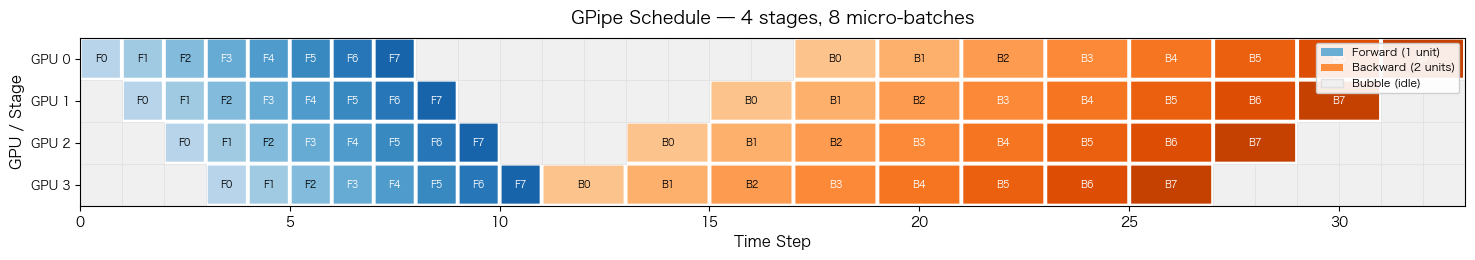

In [6]:
# GPipe：先行全部前向，后行全部反向
fig, ax = draw_pipeline_timeline(num_stages=4, num_microbatches=8, schedule="gpipe")
plt.show()

info_box(
    "GPipe 简而费存：须同时保全部八微批之<b>激活值</b>"
    "（反向传播需用之）。"
    "<br><br>"
    "<b>何谓激活值？</b>前向传播时，每层皆产中间之输出（激活值）。"
    "此须留于存中，盖反向传播计算梯度时需用之。"
    "同时处理之微批愈多 = 所存激活值愈多 = 所占器之存愈大。"
    "<br><br>"
    "存费：O(m)，m 为微批数。",
    title="GPipe 之存费"
)

### 1F1B 调度（一前一后）

GPipe 之患曰：须同时存**全部**微批之激活值，盖反向须待全部前向毕方始。可更善乎？

1F1B 之要旨：**速行反向以释存**。具言之，**末阶段**每毕一前向，即刻行其同微批之反向。此反向之果，遂向前阶段传之。

其调度分**三期**：

#### 其一：预热（充盈流水）
每阶段仅行前向 —— 尚无可反向者。微批自阶段零至一至二至三，渐充流水。

#### 其二：稳态（"一前一后"之式）
末阶段交替而行：**一前向，一反向**。每反向则释一微批之激活值。此反向之"压波"上传，使前阶段亦入一前一后之式。

#### 其三：冷却（排空流水）
不复有新前向 —— 惟余反向。每阶段行其余之反向而已。

要旨曰：以交替前向反向之法，每阶段于任一时仅须存 **O(p)** 微批之激活值，而 GPipe 须 **O(m)**。设 `p=4, m=8`，则四比八 —— 存省二倍！

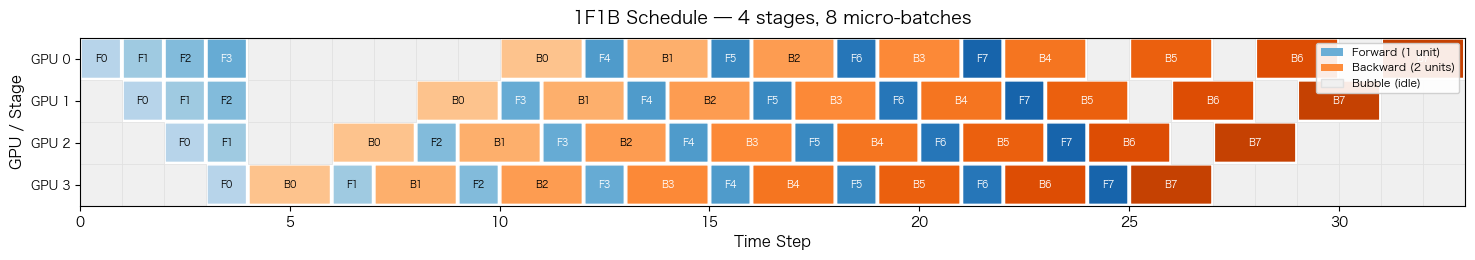

In [7]:
# 1F1B: interleave forward and backward passes
fig, ax = draw_pipeline_timeline(num_stages=4, num_microbatches=8, schedule="1f1b")
plt.show()

info_box(
    "1F1B 之泡比与 GPipe 同，然存费大减！"
    "每器仅须保 O(p) 微批之激活值"
    "（正在处理者），非全部 m 个。"
    "p=4 时：存费自 O(8) 降至 O(4)。",
    title="1F1B 之优"
)

观上方 1F1B 图中第三器（末阶段）—— 三期分明：

```
GPU 3:  [F0] [B0  B0] [F1] [B1  B1] [F2] [B2  B2] ... [F7] [B7  B7]
         ↑              ↑                                      ↑
       预热           稳态（一前向 + 一反向）                 冷却
```

再观第零器（首阶段）：须行*更多*预热前向方入一前一后之式，盖反向之信自第三器回传需时也。

**泡同而存省** —— 此即 1F1B 之权衡。泡比与 GPipe 全同，然每器之峰值存自 O(m) 降至 O(p)。

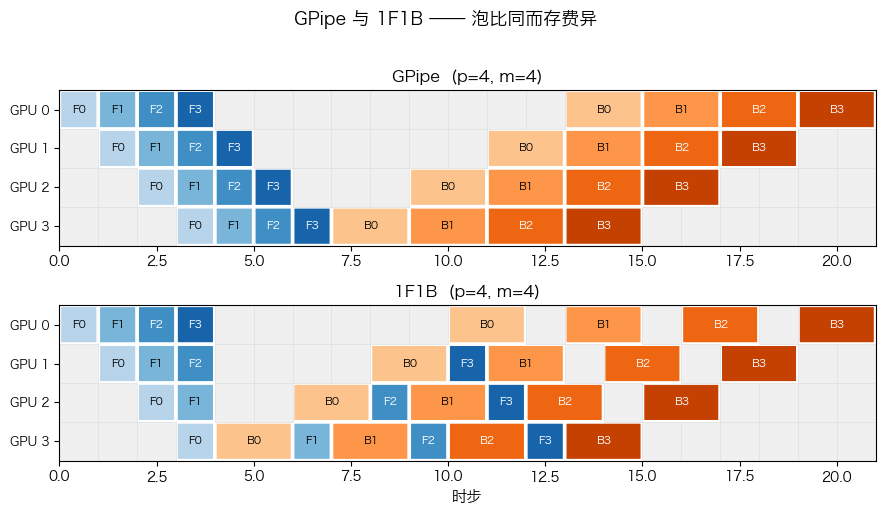

In [8]:
# 并排对比：GPipe vs 1F1B（四阶段、四微批，便于观之）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

from mp_tutorial.viz import _generate_gpipe_schedule, _generate_1f1b_schedule
import matplotlib.patches as mpatches

for ax, sched_fn, name in [(ax1, _generate_gpipe_schedule, "GPipe"),
                             (ax2, _generate_1f1b_schedule, "1F1B")]:
    sched = sched_fn(4, 4)
    fwd_cmap, bwd_cmap = plt.cm.Blues, plt.cm.Oranges
    max_time = max(t + d for t, _, _, _, d in sched)

    occupied = set()
    for t, s, m, kind, dur in sched:
        color_val = 0.3 + 0.5 * (m % 4) / 3
        color = fwd_cmap(color_val) if kind == "fwd" else bwd_cmap(color_val)
        rect = mpatches.FancyBboxPatch((t + 0.05, s + 0.05), dur - 0.1, 0.9,
            boxstyle="round,pad=0.02", facecolor=color, edgecolor="white", lw=1)
        ax.add_patch(rect)
        label = f"{'F' if kind == 'fwd' else 'B'}{m}"
        ax.text(t + dur / 2, s + 0.5, label, ha="center", va="center",
                fontsize=8, fontweight="bold", color="white" if color_val > 0.5 else "black")
        for dt in range(dur):
            occupied.add((t + dt, s))

    for t in range(max_time):
        for s in range(4):
            if (t, s) not in occupied:
                ax.add_patch(mpatches.Rectangle((t, s), 1, 1, fc="#f0f0f0", ec="#e0e0e0", lw=0.5))

    ax.set_xlim(0, max_time)
    ax.set_ylim(0, 4)
    ax.invert_yaxis()
    ax.set_yticks([s + 0.5 for s in range(4)])
    ax.set_yticklabels([f"GPU {s}" for s in range(4)], fontsize=9)
    ax.set_title(f"{name}  (p=4, m=4)", fontsize=12, fontweight="bold")
    ax.set_aspect("equal")

ax2.set_xlabel("时步", fontsize=11)
fig.suptitle("GPipe 与 1F1B —— 泡比同而存费异",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

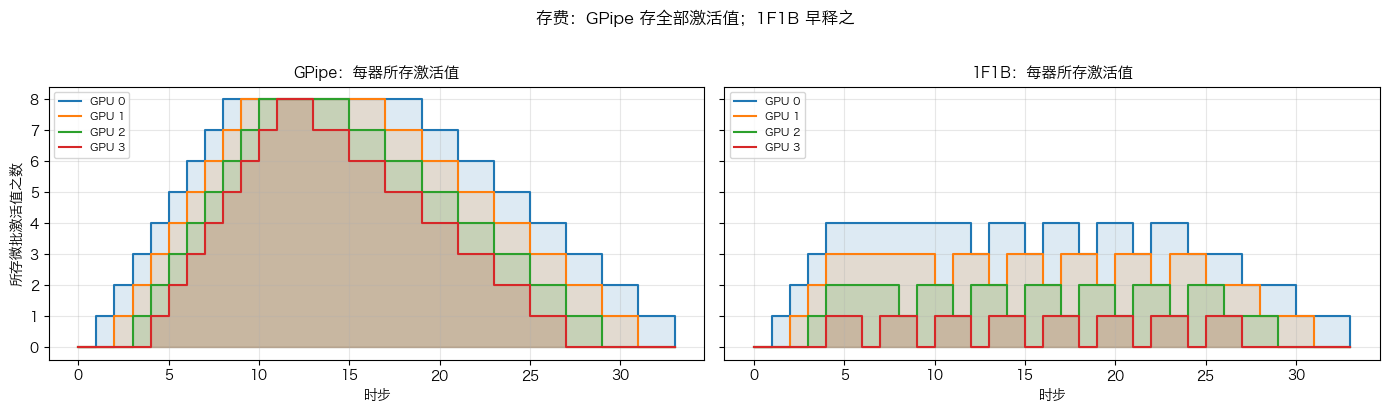

GPipe 峰值：每阶段最多存八微批之激活值（全部）
1F1B 峰值：每阶段最多存约四微批之激活值（p = 阶段数）


In [9]:
# 存之比较：每器随时存几何激活值？
# GPipe 中，前向激活值累积至反向方始。
# 1F1B 中，反向早行以释激活值。

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, sched_fn, name in [(ax1, _generate_gpipe_schedule, "GPipe"),
                             (ax2, _generate_1f1b_schedule, "1F1B")]:
    sched = sched_fn(4, 8)
    max_time = max(t + d for t, _, _, _, d in sched)

    for s in range(4):
        fwd_events = sorted([(t + dur, +1) for t, s2, m, kind, dur in sched if s2 == s and kind == "fwd"])
        bwd_events = sorted([(t + dur, -1) for t, s2, m, kind, dur in sched if s2 == s and kind == "bwd"])
        events = sorted(fwd_events + bwd_events)

        times = [0]
        counts = [0]
        count = 0
        for time, delta in events:
            times.append(time)
            counts.append(count)
            count += delta
            times.append(time)
            counts.append(count)
        times.append(max_time)
        counts.append(count)

        ax.fill_between(times, counts, alpha=0.15, color=f"C{s}")
        ax.plot(times, counts, label=f"GPU {s}", linewidth=1.5, color=f"C{s}")

    ax.set_xlabel("时步", fontsize=10)
    ax.set_title(f"{name}：每器所存激活值", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

ax1.set_ylabel("所存微批激活值之数", fontsize=10)
fig.suptitle("存费：GPipe 存全部激活值；1F1B 早释之",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("GPipe 峰值：每阶段最多存八微批之激活值（全部）")
print("1F1B 峰值：每阶段最多存约四微批之激活值（p = 阶段数）")

### 诸策对比

列其要异于一表：

In [10]:
p, m = 4, 8
comparison_table(
    headers=["调度之策", "泡比", "峰值之存", "繁简"],
    rows=[
        ["朴素（无微批）", f"{(p-1)/p:.0%}", "O(1)", "至简"],
        ["GPipe", f"{(p-1)/(m+p-1):.0%}", "O(m) = O(8)", "简"],
        ["1F1B", f"{(p-1)/(m+p-1):.0%}", "O(p) = O(4)", "中"],
        ["交错 (v=2)", f"{(p-1)/(2*m+p-1):.0%}", "O(p) = O(4)", "繁"],
    ],
    title=f"流水调度之比较（p={p} 阶段，m={m} 微批）"
)

调度之策,泡比,峰值之存,繁简
朴素（无微批）,75%,O(1),至简
GPipe,27%,O(m) = O(8),简
1F1B,27%,O(p) = O(4),中
交错 (v=2),16%,O(p) = O(4),繁


### 交错虚拟阶段（进阶）

Megatron-LM 之妙计：令每器持**多组不连续之层**（虚拟阶段），以更减其泡。

例以四器、每器二虚拟阶段：
- 第零器：第 0–1 层 **兼** 第 8–9 层
- 第一器：第 2–3 层 **兼** 第 10–11 层
- ……

泡比降为：$\frac{p-1}{v \cdot m + p-1}$（$v$ 为每器虚拟阶段之数）。其代价者，通信更频 —— 数据经每器 $v$ 次矣。

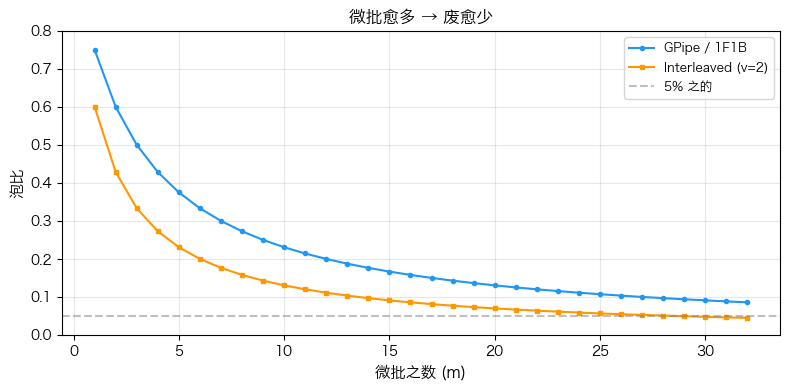

In [11]:
# How bubble fraction changes with more micro-batches
stages = 4
ms = range(1, 33)
bubble_gpipe = [(stages - 1) / (m + stages - 1) for m in ms]
bubble_interleaved = [(stages - 1) / (2 * m + stages - 1) for m in ms]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ms), bubble_gpipe, 'o-', color="#2196F3", label="GPipe / 1F1B", markersize=3)
ax.plot(list(ms), bubble_interleaved, 's-', color="#FF9800", label="Interleaved (v=2)", markersize=3)
ax.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label="5% 之的")
ax.set_xlabel("微批之数 (m)", fontsize=11)
ax.set_ylabel("泡比", fontsize=11)
ax.set_title("微批愈多 → 废愈少", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 大语言模型之应用

流水并行者，凡最大之语言模型训练皆用之：

- **GPT-3 (175B)**：八路 PP × 八路 TP，凡六十四器。PP 主节点间之通信（其费省：仅相邻阶段点对点传之）
- **Megatron-Turing NLG (530B)**：8 PP × 8 TP × 35 DP = 2240 器，用交错调度
- **通则**：TP 于节点内（高速 NVLink），PP 于节点间（仅需点对点），DP 跨副本

> **术语释义：**
> - *节点*者，一物理服务器也，通常有八器，以高速 **NVLink** 相连（600+ GB/s）
> - *跨节点*者，服务器间之通信也，走较慢之网络（InfiniBand，~400 GB/s）
> - *AllReduce*者，每器皆须与诸器通信（费大）。*点对点*者，仅与邻者通信（费小）
> - 此即 PP 宜于跨节点之故 —— 仅须与前后阶段通信耳！

In [12]:
# Why PP is preferred for inter-node communication
comparison_table(
    headers=["并行之法", "通信之式", "最宜"],
    rows=[
        ["数据并行 (DP)", "AllReduce（诸器皆互通）", "多副本同模型"],
        ["张量并行 (TP)", "层内 AllReduce", "节点内（高速 NVLink）"],
        ["流水并行 (PP)", "点对点（仅相邻阶段）", "跨节点（较慢之网）"],
    ],
    title="PP 何以为跨节点并行之首选"
)

并行之法,通信之式,最宜
数据并行 (DP),AllReduce（诸器皆互通）,多副本同模型
张量并行 (TP),层内 AllReduce,节点内（高速 NVLink）
流水并行 (PP),点对点（仅相邻阶段）,跨节点（较慢之网）


## 实践

### 需 GPU：以 PyTorch Pipe 行真正之流水线训练

In [13]:
gpu_required_banner()

In [ ]:
# [GPU-REQUIRED]
# Save as pp_train.py and run: torchrun --nproc_per_node=4 pp_train.py

"""
import torch
import torch.nn as nn
from torch.distributed.pipeline.sync import Pipe

# Place layers on different GPUs
model = nn.Sequential(
    nn.Linear(256, 512).cuda(0), nn.ReLU().cuda(0),
    nn.Linear(512, 512).cuda(1), nn.ReLU().cuda(1),
    nn.Linear(512, 256).cuda(2), nn.ReLU().cuda(2),
    nn.Linear(256, 10).cuda(3),
)

# Pipe handles micro-batch splitting automatically
pipe_model = Pipe(model, chunks=8)

optimizer = torch.optim.Adam(pipe_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for step in range(10):
    x = torch.randn(32, 256).cuda(0)
    target = torch.randint(10, (32,)).cuda(3)

    out = pipe_model(x)
    loss = loss_fn(out.local_value(), target)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Step {step}: loss={loss.item():.4f}")
"""
print("参见上方之代码 —— 运行：torchrun --nproc_per_node=4 pp_train.py")

## Megatron 参引

Megatron-LM 之流水调度，实现于 `megatron/core/pipeline_parallel/schedules.py`，其要函如下：

In [14]:
code_reference(
    code="""def forward_backward_pipelining_without_interleaving(...):
    # 1F1B Schedule
    # Phase 1: Warmup — fill pipeline with forward passes
    for i in range(num_warmup_microbatches):
        output = forward_step(...)
        send_forward(output)

    # Phase 2: Steady state — alternate 1 forward, 1 backward
    for i in range(num_microbatches_remaining):
        output = forward_step(...)
        send_forward(output)
        grad = backward_step(...)
        send_backward(grad)

    # Phase 3: Cooldown — drain remaining backward passes
    for i in range(num_warmup_microbatches):
        grad = backward_step(...)
        send_backward(grad)""",
    source="Megatron-LM",
    filepath="megatron/core/pipeline_parallel/schedules.py"
)

## 总括与延伸

### 要义

1. **流水并行**者，分模型之层于多器 —— 每器持一"阶段"
2. 无微批则同时仅一器劳作 —— 利用率极低
3. **微批**充盈流水：拆 batch 为 $m$ 份，使计算重叠
4. **泡比** $= \frac{p-1}{m+p-1}$ —— 以 $m \gg p$ 减其废
5. **GPipe**：简（先全前向后全反向），然内存大（$O(m)$）
6. **1F1B**：泡同而内存少（$O(p)$），以交替前向反向之故
7. **交错阶段**：泡再减 $v$ 倍，代价为更多通信

### 泡趋于零

上述诸策皆以流水之泡为不可免。DeepSeek 之新作挑战此说：

- **Zero Bubble Pipeline Parallelism**（Qi et al., 2023）将反向拆为二 —— **B**（激活值之梯度）与 **W**（权重之梯度）—— 独立调度之。**W** 步对上游阶段无数据之依赖，可填原本空闲之泡。所得：与 1F1B 同存费而**泡近于零**。

- **DualPipe**（DeepSeek-V3, 2024）于 MoE 模型更进一步。将每前向/反向步拆为 *attention* 与 *MoE-dispatch* 二阶段，于每微步内**重叠计算与通信**，且从流水两端双向充之。DeepSeek-V3 报以 2048 器而**几隐全部通信之费**，近满硬件之利用。

此诸法者，流水调度之当前前沿也。

### 延伸

- [GPipe (Huang et al., 2019)](https://arxiv.org/abs/1811.06965) — 微批流水并行
- [PipeDream (Narayanan et al., 2019)](https://arxiv.org/abs/1806.03377) — 1F1B 调度
- [高效大规模训练 (Narayanan et al., 2021)](https://arxiv.org/abs/2104.04473) — Megatron-LM 交错调度
- [Zero Bubble Pipeline Parallelism (Qi et al., 2023)](https://arxiv.org/abs/2401.10241) — B/W 拆分调度，泡近于零
- [DeepSeek-V3 技术报告 (2024)](https://arxiv.org/abs/2412.19437) — DualPipe：双向流水 + 计算通信之重叠
- [PyTorch 流水并行](https://pytorch.org/docs/stable/pipeline.html)
- [Megatron-LM](https://github.com/NVIDIA/Megatron-LM) — `megatron/core/pipeline_parallel/`